In [1]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel,Field

from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

c:\Coding\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
store=InMemoryStore()

In [4]:
llm=HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)

model=ChatHuggingFace(llm=llm)

In [5]:
# to avoid the duplicate memory storing add a memory item which chekc wheather the memory is already present or not

class MemoryItem(BaseModel):
    text:str=Field(description="Atomic user memory as a short sentance")
    is_new:bool=Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [6]:
class MemoryDescision(BaseModel):
    should_write:bool=Field(description="Wheather to store any Memories")
    
    # memories is the list of MemoryItem to avoid duplication
    memories:List[MemoryItem]=Field(default_factory=list,description="Atomic user memories to store")

In [7]:
# structured_model=model.with_structured_output(MemoryDescision)
from langchain_core.output_parsers import JsonOutputParser

parser = JsonOutputParser()

structured_model = model | parser

In [8]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [9]:
def remember(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1].content

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDescision = structured_model.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    # if decision["should_write"]:
    #     for mem in decision["memories"]:
    #         if mem.is_new:
    #             store.put(namespace, str(uuid.uuid4()), {"data": mem["text"]})

    for mem in decision:
       text = mem["memory"].strip()
       if mem["is_new"]:
            store.put(namespace,str(uuid.uuid4()),{"data": text})

    # if decision["should_write"]:
    #     for mem in decision["memories"]:
    #         if mem.is_new:
    #             store.put(namespace, str(uuid.uuid4()), {"data": mem["text"]})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

In [10]:
# ----------------------------
# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your responses by:
    - Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    - Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    - Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    - Greetings and transitions
    - Help or guidance tailored to tools and frameworks the user uses
    - Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user's memory (which may be empty) is provided as: {user_details_content}
"""


In [11]:
def chat_node(state:MessagesState,config:RunnableConfig,store:BaseStore):
    user_id=config['configurable']['user_id']

    user_details=("user",user_id,"details")
    items=store.search(user_details)

    if items:
        user_details_content="\n".join(f"-{it.value.get('data','')}" for it in items)
    else:
        user_details_content=""

    system_prompt=SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg=SystemMessage(content=system_prompt)

    response=model.invoke([system_msg]+state['messages'])

    return {
        'messages':[response]
    }

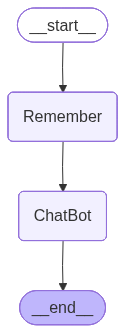

In [12]:
builder = StateGraph(MessagesState)
builder.add_node("Remember", remember)
builder.add_node("ChatBot", chat_node)

builder.add_edge(START, "Remember")
builder.add_edge("Remember","ChatBot")
builder.add_edge("Remember", END)

graph = builder.compile(store=store)

graph

In [13]:
# ----------------------------
# 7) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

In [14]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Amrit"}]}, config)
result['messages'][-1].content

'Hi Amrit! 👋 Nice to meet you. How can I help you today?  \n\n**Here are a few quick suggestions to get us started:**\n\n1.\u202fWhat projects or topics are you currently working on that you’d like some assistance with?  \n2.\u202fDo you have any favorite tools, languages, or frameworks you’d like advice on?  \n3.\u202fIs there something specific you’d like to learn or explore today (e.g., coding, data analysis, productivity tips, etc.)?  '

In [15]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user's name is Amrit.


In [16]:
result = graph.invoke({"messages": [{"role": "user", "content": "I am learning Gen Ai from YouTube"}]}, config)
print(result['messages'][-1].content)

Hi Amrit! 🎉  

It’s great that you’re diving into Generative AI through YouTube—there’s a lot of high‑quality content out there, and the visual format can make complex concepts much easier to grasp.

### Quick Tips to Make the Most of Your YouTube Learning

| Tip | Why It Helps | How to Apply It |
|-----|--------------|-----------------|
| **Create a playlist** | Keeps all the relevant videos in one place and lets you track progress. | Add every channel/lecture you find useful to a dedicated “Generative AI” playlist. |
| **Take structured notes** | Reinforces memory and gives you a reference for later projects. | Use a two‑column layout: left column for key concepts (e.g., diffusion models, transformer architecture), right column for examples or code snippets you see. |
| **Follow along with code** | Passive watching isn’t enough; hands‑on practice cements understanding. | Clone the repository (if the creator provides one) or recreate the demo in a notebook while you watch. |
| **Pause

In [17]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user's name is Amrit.
User is learning Generative AI from YouTube.


In [19]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Sure, Amrit—here’s a plain‑English rundown of what **Generative AI (GenAI)** is and how it works.

---

## 1. What “generative” means  
* **Generative** = “able to create new stuff.”  
  Instead of just recognizing pictures or answering questions, a generative model can **produce** new images, text, music, code, etc., that it has never seen before.

## 2. The core idea: learning from examples  
1. **Training data** – The model is fed a massive collection of examples (e.g., billions of words, millions of photos).  
2. **Pattern hunting** – Using deep neural networks, it learns statistical patterns: “In English, the word ‘cat’ is often followed by ‘sits’,” or “A sky‑blue background often appears with clouds.”  
3. **Probability model** – The network ends up estimating the probability of the next piece of data given what it has already seen.

## 3. How generation works  
When you ask the model to “generate” something, it:
1. **Starts with a prompt** (a few words, a sketch, a melody fragme

In [20]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user's name is Amrit.
User is learning Generative AI from YouTube.
